In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 177M/177M [00:10<00:00, 18.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1):
['Car Brand Classification Dataset']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'test'))}")

Contents of the 'train' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']
Contents of the 'test' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train) ---
Found 11517 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train. Displaying 6 samples:


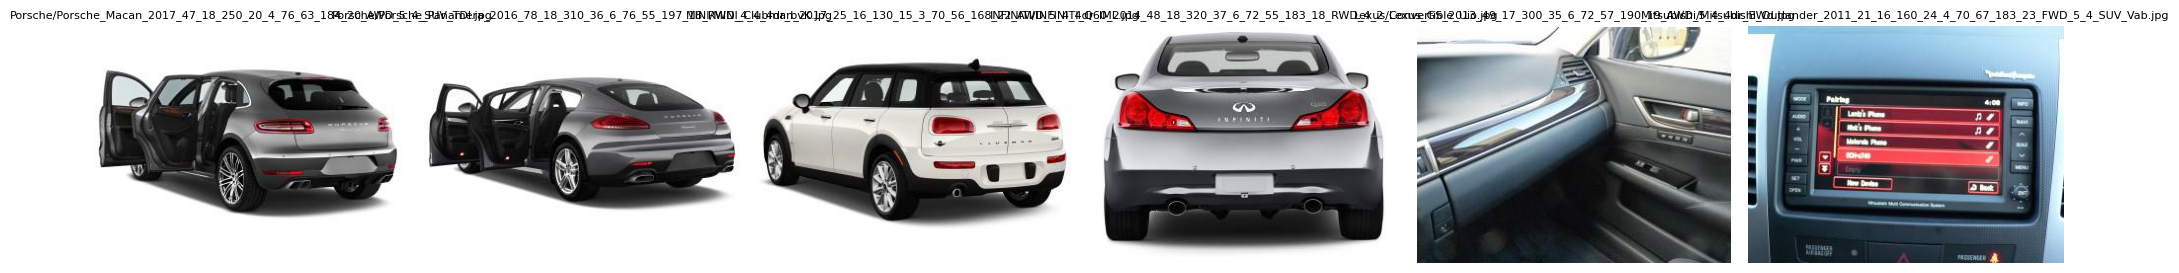


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test) ---
Found 2475 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test. Displaying 6 samples:


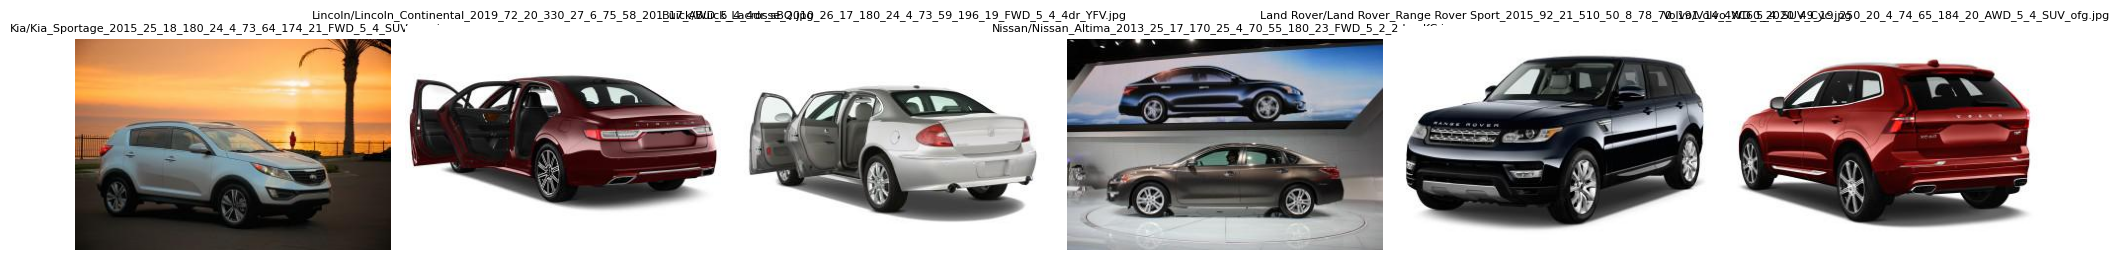

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Car Brand Classification Dataset' subdirectory
train_path = os.path.join(path, 'Car Brand Classification Dataset', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Car Brand Classification Dataset', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Data preprocessing and AlexNet definition
# AlexNet expects 224x224 images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

# Define AlexNet architecture
class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# Training Loop
epochs = 10
history = {'train_loss': [], 'test_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history['test_acc'].append(accuracy)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 3.4977, Accuracy: 3.11%
Epoch [2/10], Loss: 3.4906, Accuracy: 4.77%
Epoch [3/10], Loss: 3.4688, Accuracy: 5.82%
Epoch [4/10], Loss: 3.4136, Accuracy: 7.96%
Epoch [5/10], Loss: 3.3025, Accuracy: 9.94%
Epoch [6/10], Loss: 3.1868, Accuracy: 12.85%
Epoch [7/10], Loss: 3.0346, Accuracy: 15.80%
Epoch [8/10], Loss: 2.8552, Accuracy: 18.26%
Epoch [9/10], Loss: 2.6121, Accuracy: 21.66%
Epoch [10/10], Loss: 2.3355, Accuracy: 25.58%


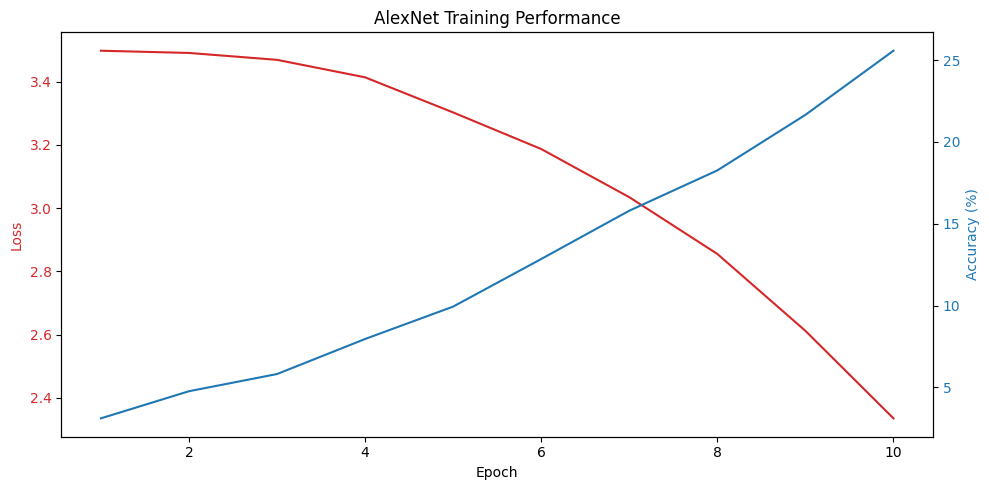

In [ ]:
# Plotting the training results
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(1, epochs + 1), history['train_loss'], color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='tab:blue')
ax2.plot(range(1, epochs + 1), history['test_acc'], color='tab:blue', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('AlexNet Training Performance')
fig.tight_layout()
plt.show()